## RAG Chatbot Implementation
This notebook implements a RAG workflow powered by a Groq LLM Model. 

### Step 1. Setting up the environment
Ensures that required imports, environment variables and file paths has been set up.

In [41]:
import json
import logging
import os
import sys
from uuid import uuid4

from dotenv import load_dotenv
from langchain.messages import AIMessage
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from pydantic import BaseModel, ConfigDict, Field

sys.path.append(os.path.abspath(".."))

from app.backend.prompts.prompt_manager import JinjaPromptManager

In [42]:
# Load environment
load_dotenv()

# Set up Embedding model
OPENAI_EMB_MODEL = os.getenv("OPENAI_EMB_MODEL", "text-embedding-3-small")

# Set up LLM Config
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
GROQ_MODEL = os.getenv("GROQ_MODEL", "llama-3.1-8b-instant")

# Set up monitoring
LANGCHAIN_API_KEY = os.getenv("LANGCHAIN_API_KEY")
LANGCHAIN_TRACING_V2 = os.getenv("LANGCHAIN_TRACING_V2", "true")
LANGCHAIN_PROJECT = os.getenv("LANGCHAIN_PROJECT", "AI-Clinical-Assistant")

# Set up os environ
os.environ["LANGSMITH_API_KEY"] = LANGCHAIN_API_KEY
os.environ["LANGSMITH_TRACING"] = LANGCHAIN_TRACING_V2
os.environ["LANGSMITH_PROJECT"] = LANGCHAIN_PROJECT

In [43]:
CWD = os.getcwd()
ROOT = os.path.abspath(os.path.join(CWD, ".."))


# Create Function to create a directory
def create_folder(relative_path: str):
    """
    Helper function to create a folder if it does not exists and return file path

    Args:
        relative_path (str): Relative Path with respect to root

    Returns:
        str: String containing absolute file path
    """
    path = os.path.join(ROOT, relative_path)
    try:
        os.makedirs(path, exist_ok=True)
        print(f"Ensured directory '{path}' exists")
    except OSError as exc:
        print(f"Exception faced when creating folder '{path}': {exc}")
    return os.path.abspath(path)


# Set up necessary saving points
FAISS_DIR = create_folder(relative_path="app/backend/database/faiss")

Ensured directory 'c:\DBTT\DBTT_G5T1\app/backend/database/faiss' exists


In [44]:
# Set up logger
logger = logging.getLogger(__name__)
logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s - %(message)s",
)

### Step 2. Define State Object
State object is parsed from node to node in the RAG workflow to allow for prompt chaining.

In [45]:
class State(BaseModel):
    """A base state object for a RAG Workflow."""

    # Business logic  (Required Field)
    user_id: str = Field(..., description="Unique identifier for the user.")
    session_id: str = Field(..., description="Unique identifier for the session.")

    # User Query (Required Field)
    user_query: str = Field(..., description="User Query")

    # Conversation History
    conversation_history: list[dict] = Field(
        default_factory=list,
        description="List of conversation history within the same session",
    )

    # Sources
    sources: list[dict] = Field(
        default_factory=list, description="List of sources extracted from vector store"
    )

    # LLM Output
    content: str | None = Field(default=None, description="LLM Response")

    # Usage Data
    response_metadata: dict = Field(
        default_factory=dict, description="LLM Response Metadata"
    )

    model_config = ConfigDict(extra="ignore")

### Step 3: Setting up RAG workflow
Creation of LLM client, prompt manager, RAG workflow components

In [46]:
# Setting up LLM Groq Client and Prompt Manager
llm_client = ChatGroq(api_key=GROQ_API_KEY, model=GROQ_MODEL)
prompt_manager = JinjaPromptManager()

In [47]:
class SourceRetrievalComponent:
    """
    The source retrieval component obtains relevant chunks from the local vector store
    """

    def __init__(self, name: str = "faiss_index", num_sources: int = 4):
        # Instantiate vector store path
        vector_store_path = os.path.join(FAISS_DIR, name)
        self.num_sources = num_sources

        # Load FAISS config
        with open(os.path.join(FAISS_DIR, "faiss_config.json"), "r") as f:
            config: dict = json.load(f)
            self.metadata: dict = config.get("metadata", {})

        # Set up embedding model
        embeddings = OpenAIEmbeddings(
            model=self.metadata.get("embedding_model", OPENAI_EMB_MODEL)
        )

        # Security risk as it involves unpickling data from the index.pkl file, ensure that .pkl is not tampered with
        self.vectorstore = FAISS.load_local(
            vector_store_path, embeddings, allow_dangerous_deserialization=True
        )

    async def retrieve(self, state: State):
        """
        Retrieve sources based on the user query

        Args:
            state: State that contains information about "user_query"

        Returns:
            state: Updated state containing the "sources"
        """
        try:
            sources = self.vectorstore.similarity_search(
                state.user_query, k=self.num_sources
            )
            return {"sources": [source.model_dump() for source in sources]}

        except Exception as exc:
            logger.exception("Exception occurred: %s", exc)
            return {}

In [48]:
# Setting up Source Retrieval Component
source_retrieval = SourceRetrievalComponent(
    name="faiss_index",
    num_sources=4,
)

In [49]:
class ResponseSynthesiserComponent:
    """
    The response synthesizer component synthesizes a response based on user query, conversation history and content from retrieved sources.
    """

    SYNTHESIZE_RESPONSE_PROMPT = "response_synthesis.yaml"

    def __init__(
        self,
        llm_client: ChatOpenAI | ChatGroq,
        prompt_manager: JinjaPromptManager,
        prompt_filename: str | None = None,
    ):
        self.llm_client = llm_client
        self.prompt_manager = prompt_manager

        # Shadow the class defaults on the instance (copy to avoid shared mutation)
        self.prompt_filename = prompt_filename or type(self).SYNTHESIZE_RESPONSE_PROMPT

        # Extract out template and mandatory args
        template, mandatory_args = self.prompt_manager.load_prompt(self.prompt_filename)
        self.prompt_template: ChatPromptTemplate = template
        self.mandatory_args: list[str] = mandatory_args

    async def synthesize(self, state: State):
        """
        Synthesizes a response based on the user query, conversation history and content from retrieved sources.

        Args:
            state: State that contains information about "user_query"

        Returns:
            state: Updated state containing the "content" and "usage"
        """
        try:
            # Craft prompt including user query, content from retrieved sources and conversation history.
            args: dict = {
                "user_query": state.user_query,
                "sources": (
                    "\n".join(
                        f"**Source {i+1}:** {source['page_content']}"
                        for i, source in enumerate(state.sources)
                    )
                    if state.sources
                    else None
                ),
                "conversation_history": (
                    "\n".join(
                        f"**User:** {history.get('user_query')}\n**Assistant:** {history.get('content')}"
                        for history in state.conversation_history
                    )
                    if state.conversation_history
                    else None
                ),
            }
            filtered_args = {k: v for k, v in args.items() if v is not None}
            self.prompt_manager.validate_inputs(
                filtered_args.keys(), self.mandatory_args
            )
            prompt = self.prompt_template.format_messages(**filtered_args)
            response: AIMessage = await self.llm_client.ainvoke(prompt)
            return {
                "content": response.content,
                "response_metadata": response.response_metadata,
            }

        except Exception as exc:
            logger.exception("Exception occurred: %s", exc)
            return {"content": exc, "response_metadata": {}}

In [50]:
# Setting up Response Synthesiser
response_synthesiser = ResponseSynthesiserComponent(
    llm_client=llm_client,
    prompt_manager=prompt_manager,
    prompt_filename="response_synthesis.yaml",
)

### Step 3. Define State Object
State object is parsed from node to node in the RAG workflow to allow for prompt chaining.

In [51]:
class State(BaseModel):
    """A base state object for a RAG Workflow."""

    # Business logic  (Required Field)
    user_id: str = Field(..., description="Unique identifier for the user.")
    session_id: str = Field(..., description="Unique identifier for the session.")

    # User Query (Required Field)
    user_query: str = Field(..., description="User Query")

    # Conversation History
    conversation_history: list[dict] = Field(
        default_factory=list,
        description="List of conversation history within the same session",
    )

    # Sources
    sources: list[dict] = Field(
        default_factory=list, description="List of sources extracted from vector store"
    )

    # LLM Output
    content: str | None = Field(default=None, description="LLM Response")

    # Usage Data
    response_metadata: dict = Field(
        default_factory=dict, description="LLM Response Metadata"
    )

    model_config = ConfigDict(extra="ignore")

### Step 4: Build State Graph structure for orchestration

In [52]:
# Create function for extracting conversation history


async def extract_conversation_history(state: State):
    # Requires connecting to MongoDB which has been performed in the application
    # Check out app/backend/database/mongodb.py for full implementation
    return {"conversation_history": []}

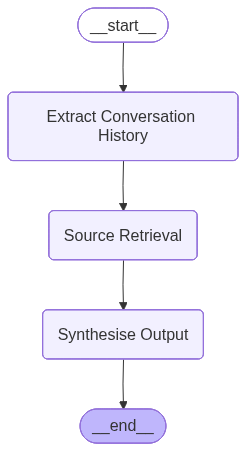

In [53]:
from IPython.display import Image, display
from langgraph.graph import END, START, StateGraph

# Instantiate graph here
graph_builder = StateGraph(State)

# Include nodes
graph_builder.add_node("Extract Conversation History", extract_conversation_history)
graph_builder.add_node("Source Retrieval", source_retrieval.retrieve)
graph_builder.add_node("Synthesise Output", response_synthesiser.synthesize)

# Include Edges
graph_builder.add_edge(START, "Extract Conversation History")
graph_builder.add_edge("Extract Conversation History", "Source Retrieval")
graph_builder.add_edge("Source Retrieval", "Synthesise Output")
graph_builder.add_edge("Synthesise Output", END)

# Compile and save graph
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

### Step 5. Invocation
Sample invocation of workflow

In [54]:
# Invoke Sample Response
response = await graph.ainvoke(
    {
        "user_id": str(uuid4()),
        "session_id": str(uuid4()),
        "user_query": "What is Cold Sores?",
    }
)
print(json.dumps(response, indent=4))

INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


{
    "user_id": "f9a7b53d-68ff-432f-9734-707db76790db",
    "session_id": "33ea6c11-bd1f-4f8a-a9ee-d4bbbfa52a62",
    "user_query": "What is Cold Sores?",
    "conversation_history": [],
    "sources": [
        {
            "id": "3e364c0a-2aae-4dd3-80af-0fdfa6045fb0",
            "metadata": {
                "source": "https://www.healthhub.sg/health-conditions/cold-sores",
                "title": "Cold Sores",
                "language": "en"
            },
            "page_content": "What are the possible causes of Cold Sores?\nCold sores are mostly caused by an infection with the Herpes Simplex Virus (HSV). Once infected with the HSV, the virus remains in the body for life. Cold sores may not appear again if the HSV remains inactive. However, the HSV may become active and cause cold sores via the following triggers:Exposure to strong sunlight, cold or windStress or fatigueWeakened immune systemFever or infectionHormonal changes (e.g. menses)\n\nWhat are the symptoms of Cold S